In [1]:
# Librerías

import tensorflow as tf
print('Tensorflow: ', tf.__version__)

from tensorflow import keras
print('Keras: ', keras.__version__)

from tensorflow.keras import callbacks
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from skimage.io import imread
from skimage.transform import resize

# Ruta dataset

dataset_path = "data"
print(os.listdir(dataset_path))

Tensorflow:  2.21.0
Keras:  3.14.1
['damaged', 'intact']


Número de imágenes:  400
Resolución de las imágenes: 125x94x3
Número de clases:  2
Clases:  ['damaged', 'intact']


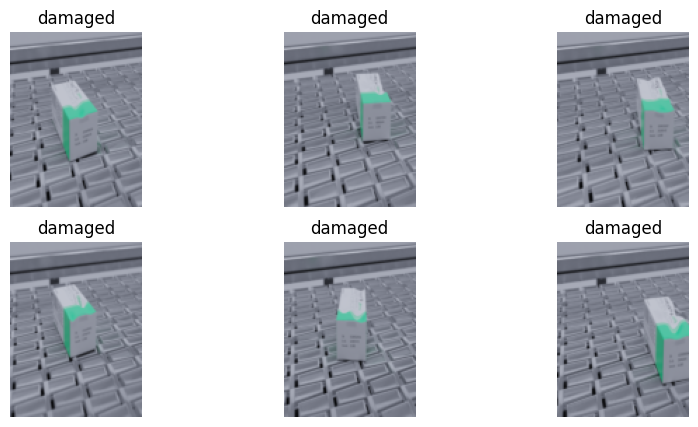

In [2]:
# Cargar imágenes y etiquetarlas

images = []
target = []

class_names = ["damaged", "intact"]

for class_index, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    
    for view in ["side", "top"]:
        view_path = os.path.join(class_path, view)
        
        for image_name in os.listdir(view_path):
            image_path = os.path.join(view_path, image_name)
            image = imread(image_path)
            image = resize(image, (125, 94, 3))
            
            images.append(image)
            target.append(class_index)

images = np.array(images)
target = np.array(target)

num_images, height, width, channels = images.shape

print("Número de imágenes: ", num_images)
print(f"Resolución de las imágenes: {height}x{width}x{channels}")
print("Número de clases: ", len(np.unique(target)))
print("Clases: ", class_names)

# Visualización de algunas imágenes (prueba)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[target[i]])
    plt.axis("off")

plt.show()

In [8]:
# Train/test

X_train, X_test, y_train, y_test = train_test_split(images, target, test_size=0.2, random_state=0, stratify=target)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Normalización

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

Train: (320, 125, 94, 3)
Test: (80, 125, 94, 3)


In [9]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(125, 94, 3)
)

conv_base.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 125, 94, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 125, 94, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 125, 94, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 62, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 62, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 62, 47, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 31, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 31, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 31, 23, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 31, 23, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 15, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 15, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 15, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 15, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 7, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
## Fijar capas 

conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 125, 94, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 125, 94, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 125, 94, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 62, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 62, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 62, 47, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 31, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 31, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 31, 23, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 31, 23, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 15, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 15, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 15, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 15, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 7, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 7, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
# Modelo de clasificación

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,108,161 (57.63 MB)

 Trainable params: 393,473 (1.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
# Compilación del modelo

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(),
    metrics=['accuracy']
)

In [13]:
# Entrenamiento inicial

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - accuracy: 0.5352 - loss: 0.8506 - val_accuracy: 0.5469 - val_loss: 0.6900
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.5078 - loss: 0.7449 - val_accuracy: 0.4531 - val_loss: 0.6933
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step - accuracy: 0.4570 - loss: 0.7448 - val_accuracy: 0.4531 - val_loss: 0.7066
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step - accuracy: 0.4805 - loss: 0.7198 - val_accuracy: 0.4531 - val_loss: 0.6961
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 391ms/step - accuracy: 0.5117 - loss: 0.6971 - val_accuracy: 0.4531 - val_loss: 0.6960
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.4766 - loss: 0.7113 - val_accuracy: 0.4531 - val_loss: 0.6948
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step - accuracy: 0.4922 - loss: 0.6994 - val_accuracy: 0.5469 - val_loss: 0.6922
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.4922 - loss: 0.6949 - val_accuracy: 0.4531 - val_loss:

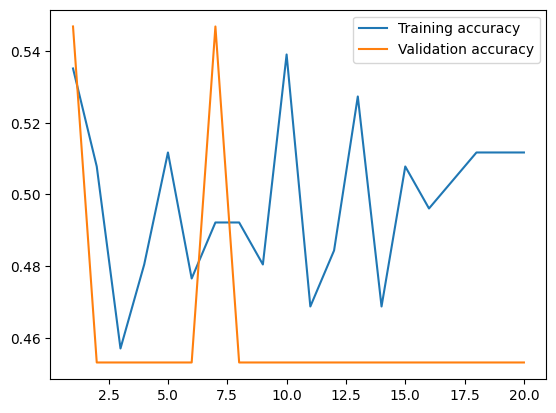

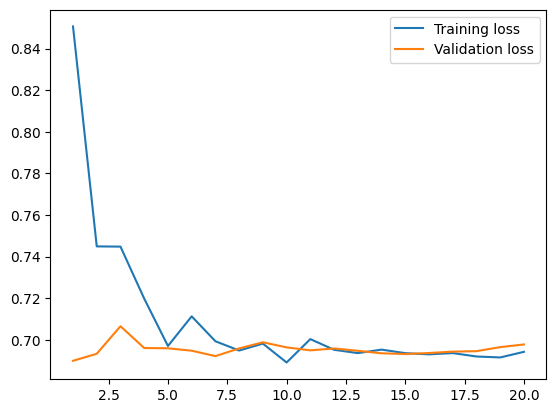

In [14]:
# Gráficas de accuracy y loss

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.legend()
plt.show()

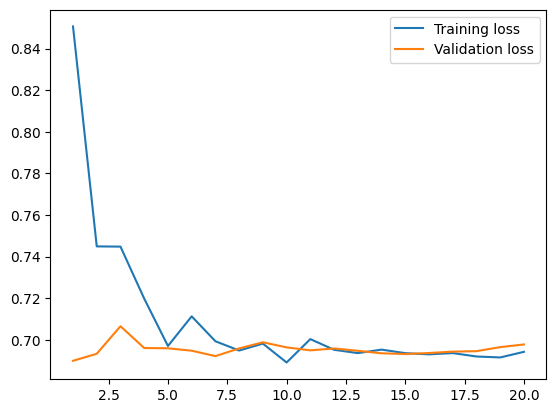

In [16]:
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.legend()
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.5000 - loss: 0.6940
Test accuracy: 0.5
Test loss: 0.6939806342124939


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step


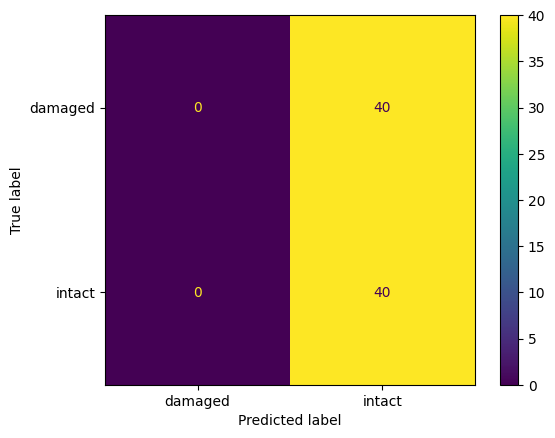

In [18]:
# Predicciones y matriz de confusión

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot()
plt.show()

In [19]:
# Métricas de clasificación

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     damaged       0.00      0.00      0.00        40
      intact       0.50      1.00      0.67        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



c:\Users\marti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [20]:
# Validación cruzada 5-fold para VGG16 base

num_folds = 5
epochs = 10
batch_size = 32

kfold = KFold(n_splits=num_folds, shuffle=True, random_state=0)

fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train, test in kfold.split(images, target):

    X_train_fold = images[train].astype("float32") / 255
    X_test_fold = images[test].astype("float32") / 255
    y_train_fold = target[train]
    y_test_fold = target[test]

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()
    model.add(conv_base)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(),
                  metrics=['accuracy'])

    print('------------------------------------------------------------------------')
    print(f'Entrenando fold {fold_no}')

    history = model.fit(X_train_fold, y_train_fold,
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=1)

    scores = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    print(f'Score para fold {fold_no}: {model.metrics_names[1]} = {scores[1]} ; {model.metrics_names[0]} = {scores[0]}')

    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])

    fold_no = fold_no + 1

print('------------------------------------------------------------------------')
print('Resultados por fold')
for i in range(0, len(acc_per_fold)):
    print(f'Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}')

print('------------------------------------------------------------------------')
print('Resultados medios')
print(f'Accuracy media: {np.mean(acc_per_fold)}')
print(f'Desviación accuracy: {np.std(acc_per_fold)}')
print(f'Loss media: {np.mean(loss_per_fold)}')

------------------------------------------------------------------------
Entrenando fold 1
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.5188 - loss: 0.7662
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.5063 - loss: 0.7498
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 349ms/step - accuracy: 0.5250 - loss: 0.7106
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step - accuracy: 0.5125 - loss: 0.7020
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.5031 - loss: 0.6994
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.5094 - loss: 0.6970
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 297ms/step - accuracy: 0.5281 - loss: 0.6932
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - accuracy: 0.5437 - loss: 0.6956
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.5156 - loss: 0.6962
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.5063 - loss: 0.6920
Score para fold 1: compile_metrics = 0.425000011

In [22]:
# Modelo base MobileNetV2

conv_base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
conv_base_mobilenet.trainable = False

model_mobilenet = models.Sequential()
model_mobilenet.add(conv_base_mobilenet)
model_mobilenet.add(layers.Flatten())
model_mobilenet.add(layers.Dense(128, activation='relu'))
model_mobilenet.add(layers.Dropout(0.5))
model_mobilenet.add(layers.Dense(1, activation='sigmoid'))

model_mobilenet.compile(loss='binary_crossentropy',
                        optimizer=optimizers.Adam(),
                        metrics=['accuracy'])

model_mobilenet.summary()

C:\Users\marti\AppData\Local\Temp\ipykernel_26912\1673885208.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(125, 94, 3))


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 4, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,224,321 (16.11 MB)

 Trainable params: 1,966,337 (7.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
# Entrenamiento inicial MobileNetV2

history_mobilenet = model_mobilenet.fit(X_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

test_loss_mobilenet, test_acc_mobilenet = model_mobilenet.evaluate(X_test, y_test)

print("Test accuracy MobileNetV2:", test_acc_mobilenet)
print("Test loss MobileNetV2:", test_loss_mobilenet)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.4883 - loss: 5.1173 - val_accuracy: 0.5781 - val_loss: 0.6810
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5078 - loss: 1.8224 - val_accuracy: 0.5469 - val_loss: 0.7142
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5117 - loss: 0.8892 - val_accuracy: 0.5469 - val_loss: 0.6919
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5312 - loss: 0.6925 - val_accuracy: 0.4531 - val_loss: 0.6933
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.4531 - val_loss: 0.6933
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.4531 - val_loss: 0.6933
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.4531 - val_loss: 0.6934
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.4531 - val_loss: 0.6934

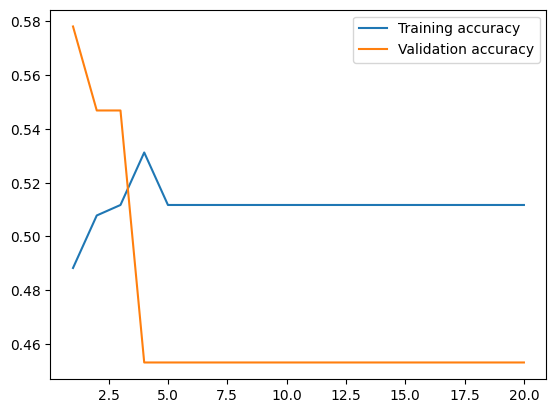

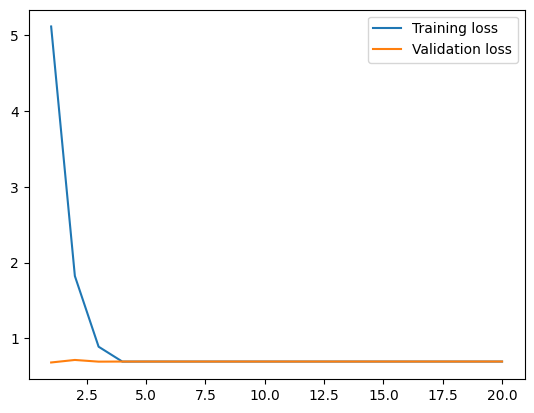

In [27]:
# Gráficas accuracy y loss MobileNetV2

acc_mobilenet = history_mobilenet.history['accuracy']
val_acc_mobilenet = history_mobilenet.history['val_accuracy']

loss_mobilenet = history_mobilenet.history['loss']
val_loss_mobilenet = history_mobilenet.history['val_loss']

epochs = range(1, len(acc_mobilenet) + 1)

plt.plot(epochs, acc_mobilenet, label='Training accuracy')
plt.plot(epochs, val_acc_mobilenet, label='Validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss_mobilenet, label='Training loss')
plt.plot(epochs, val_loss_mobilenet, label='Validation loss')
plt.legend()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step


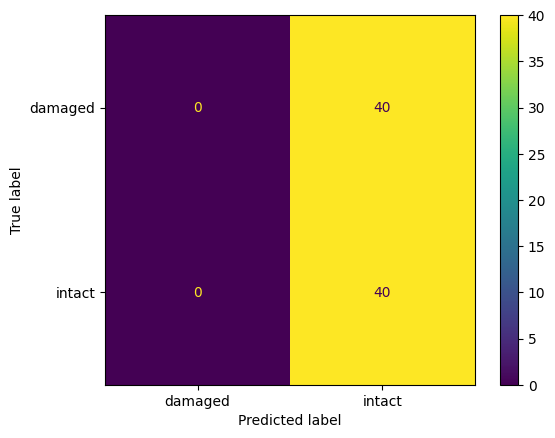

In [28]:
# Predicciones y matriz de confusión MobileNetV2

y_pred_mobilenet = model_mobilenet.predict(X_test)
y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype("int32")

cm_mobilenet = confusion_matrix(y_test, y_pred_mobilenet)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mobilenet, display_labels=class_names)

disp.plot()
plt.show()

In [31]:
# Pruebas preliminares de batch size

batch_values = [16, 32]

for batch_value in batch_values:

    print('------------------------------------------------------------------------')
    print(f'Batch size: {batch_value}')

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()

    model.add(conv_base)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(),
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        batch_size=batch_value,
                        validation_split=0.2,
                        verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f'Accuracy test: {test_acc}')
    print(f'Loss test: {test_loss}')

------------------------------------------------------------------------
Batch size: 16
Accuracy test: 0.5
Loss test: 0.6933819055557251
------------------------------------------------------------------------
Batch size: 32
Accuracy test: 0.5
Loss test: 0.6950680613517761


In [32]:
# Pruebas preliminares de learning rate

learning_rate_values = [0.001, 0.0001]

for learning_rate_value in learning_rate_values:

    print('------------------------------------------------------------------------')
    print(f'Learning rate: {learning_rate_value}')

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()

    model.add(conv_base)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(learning_rate=learning_rate_value),
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f'Accuracy test: {test_acc}')
    print(f'Loss test: {test_loss}')

------------------------------------------------------------------------
Learning rate: 0.001
Accuracy test: 0.5
Loss test: 0.6942137479782104
------------------------------------------------------------------------
Learning rate: 0.0001
Accuracy test: 0.5
Loss test: 0.6939006447792053


In [33]:
# Comparación inicial del efecto del dropout

dropout_values = [0.3, 0.5]

for dropout_value in dropout_values:

    print('------------------------------------------------------------------------')
    print(f'Dropout: {dropout_value}')

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()
    model.add(conv_base)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_value))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(),
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f'Accuracy test: {test_acc}')
    print(f'Loss test: {test_loss}')

------------------------------------------------------------------------
Dropout: 0.3
Accuracy test: 0.5
Loss test: 0.6982600092887878
------------------------------------------------------------------------
Dropout: 0.5
Accuracy test: 0.5
Loss test: 0.693178653717041


In [34]:
# Comparación inicial del número de neuronas

neurons_values = [64, 128, 256]

for neurons in neurons_values:

    print('------------------------------------------------------------------------')
    print(f'Número de neuronas: {neurons}')

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()

    model.add(conv_base)
    model.add(layers.Flatten())
    model.add(layers.Dense(neurons, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(), metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f'Accuracy test: {test_acc}')
    print(f'Loss test: {test_loss}')


------------------------------------------------------------------------
Número de neuronas: 64
Accuracy test: 0.5
Loss test: 0.6931523084640503
------------------------------------------------------------------------
Número de neuronas: 128
Accuracy test: 0.5
Loss test: 0.6932194828987122
------------------------------------------------------------------------
Número de neuronas: 256
Accuracy test: 0.5
Loss test: 0.694101870059967


In [35]:
# Comparación inicial del número de capas de clasificación

layers_values = [1, 2, 3]

for num_layers in layers_values:

    print('------------------------------------------------------------------------')
    print(f'Número de capas: {num_layers}')

    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
    conv_base.trainable = False

    model = models.Sequential()
    model.add(conv_base)
    model.add(layers.Flatten())

    for i in range(num_layers):
        model.add(layers.Dense(128, activation='relu'))

    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(),
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                    
                        epochs=10,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f'Accuracy test: {test_acc}')
    print(f'Loss test: {test_loss}')

------------------------------------------------------------------------
Número de capas: 1
Accuracy test: 0.5
Loss test: 0.6934673190116882
------------------------------------------------------------------------
Número de capas: 2
Accuracy test: 0.5
Loss test: 0.6950511932373047
------------------------------------------------------------------------
Número de capas: 3
Accuracy test: 0.5
Loss test: 0.6931455731391907


In [ ]:
# Barrido final de configuraciones con validación cruzada 5-fold

layers_values = [1, 2, 3]
neurons_values = [64, 128, 256]
dropout_values = [0.3, 0.5]

num_folds = 5
epochs = 10
batch_size = 32

results = []

for num_layers in layers_values:
    for neurons in neurons_values:
        for dropout_value in dropout_values:

            print('------------------------------------------------------------------------')
            print(f'Capas: {num_layers} - Neuronas: {neurons} - Dropout: {dropout_value}')

            kfold = KFold(n_splits=num_folds, shuffle=True, random_state=0)

            acc_per_fold = []
            loss_per_fold = []

            for train, test in kfold.split(images, target):

                X_train_fold = images[train].astype("float32") / 255
                X_test_fold = images[test].astype("float32") / 255
                y_train_fold = target[train]
                y_test_fold = target[test]

                conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(125, 94, 3))
                conv_base.trainable = False

                model = models.Sequential()
                model.add(conv_base)
                model.add(layers.Flatten())

                for i in range(num_layers):
                    model.add(layers.Dense(neurons, activation='relu'))

                model.add(layers.Dropout(dropout_value))
                model.add(layers.Dense(1, activation='sigmoid'))

                model.compile(loss='binary_crossentropy',
                              optimizer=optimizers.Adam(),
                              metrics=['accuracy'])

                history = model.fit(X_train_fold, y_train_fold,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    verbose=0)

                scores = model.evaluate(X_test_fold, y_test_fold, verbose=0)

                acc_per_fold.append(scores[1])
                loss_per_fold.append(scores[0])

            results.append([num_layers, neurons, dropout_value,
                            np.mean(acc_per_fold), np.std(acc_per_fold),
                            np.mean(loss_per_fold)])

            print(f'Accuracy media: {np.mean(acc_per_fold)}')
            print(f'Desviación accuracy: {np.std(acc_per_fold)}')
            print(f'Loss media: {np.mean(loss_per_fold)}')

results_df = pd.DataFrame(results, columns=['Capas', 'Neuronas', 'Dropout', 'Accuracy media', 'Desviación accuracy', 'Loss media'])
results_df

------------------------------------------------------------------------
Capas: 1 - Neuronas: 64 - Dropout: 0.3
Accuracy media: 0.4850000083446503
Desviación accuracy: 0.038242648456044734
Loss media: 0.6942956924438477
------------------------------------------------------------------------
Capas: 1 - Neuronas: 64 - Dropout: 0.5
Accuracy media: 0.47000000476837156
Desviación accuracy: 0.028062425940401373
Loss media: 0.6948041677474975
------------------------------------------------------------------------
Capas: 1 - Neuronas: 128 - Dropout: 0.3
Accuracy media: 0.47000000476837156
Desviación accuracy: 0.028062425940401373
Loss media: 0.6948725342750549
------------------------------------------------------------------------
Capas: 1 - Neuronas: 128 - Dropout: 0.5
Accuracy media: 0.47000000476837156
Desviación accuracy: 0.028062425940401373
Loss media: 0.6955050945281982
------------------------------------------------------------------------
Capas: 1 - Neuronas: 256 - Dropout: 0.3
Ac

,Capas,Neuronas,Dropout,Accuracy media,Desviación accuracy,Loss media
0,1,64,0.3,0.485,0.038243,0.694296
1,1,64,0.5,0.470,0.028062,0.694804
2,1,128,0.3,0.470,0.028062,0.694873
3,1,128,0.5,0.470,0.028062,0.695505
4,1,256,0.3,0.500,0.041079,0.694288
5,1,256,0.5,0.470,0.028062,0.695851
6,2,64,0.3,0.470,0.028062,0.696305
7,2,64,0.5,0.470,0.028062,0.694355
8,2,128,0.3,0.470,0.028062,0.697168
9,2,128,0.5,0.470,0.028062,0.695691


In [ ]:

# Mejor configuración obtenida

best_result = results_df.loc[results_df['Accuracy media'].idxmax()]

print('Mejor configuración encontrada')
print(best_result)

Mejor configuración encontrada
Capas                    1.000000
Neuronas               256.000000
Dropout                  0.300000
Accuracy media           0.500000
Desviación accuracy      0.041079
Loss media               0.694288
Name: 4, dtype: float64


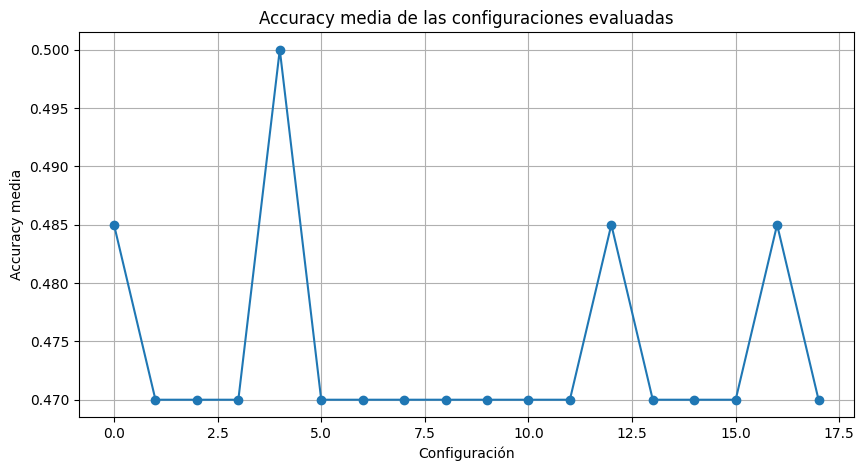

In [ ]:
# Gráfica comparativa de las configuraciones

plt.figure(figsize=(10, 5))
plt.plot(results_df.index, results_df['Accuracy media'], marker='o')
plt.xlabel('Configuración')
plt.ylabel('Accuracy media')
plt.title('Accuracy media de las configuraciones evaluadas')
plt.grid()
plt.show()